# EDA – E-commerce Fraud Data (`Fraud_Data.csv`)

**What this notebook covers (Task 1):**
1. Load and inspect the raw data
2. Clean the data — missing values, duplicates, data types
3. Univariate and bivariate distributions
4. Class imbalance analysis
5. IP geolocation enrichment (IP address → Country)
6. Save the cleaned dataset for feature engineering

**Dataset quick facts:**
| Item | Value |
|------|-------|
| Rows | 151,112 |
| Columns | 11 |
| Missing values | None |
| Duplicates | None |
| Fraud rate | **9.36%** |

## 1. Setup & Imports

In [1]:
# ── Standard library ──────────────────────────────────────────────────
import os
import sys

# ── Data manipulation ─────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Add src/ to path so we can import our helper functions ─────────────
# Going up one level (..) from notebooks/ brings us to the project root
sys.path.append(os.path.join('..'))
from src.preprocessing import ip_float_to_int, merge_ip_country, class_distribution
print(f"preprocessing module imported successfully: {', '.join(dir())}")

# ── Display settings ──────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

# ── Paths ─────────────────────────────────────────────────────────────
DATA_RAW       = os.path.join('..', 'data', 'raw')
DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIGURES_DIR    = 'figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
print('✓ Setup complete')

preprocessing module imported successfully: In, Out, _, __, ___, __builtin__, __builtins__, __doc__, __loader__, __name__, __package__, __spec__, __vsc_ipynb_file__, _dh, _i, _i1, _ih, _ii, _iii, _oh, class_distribution, exit, get_ipython, ip_float_to_int, merge_ip_country, np, open, os, pd, plt, quit, sns, sys
✓ Setup complete


## 2. Load Data

In [2]:
# pd.read_csv with parse_dates converts date strings → Timestamp objects
# so we can do arithmetic like (purchase_time - signup_time) later
fraud = pd.read_csv(
    os.path.join(DATA_RAW, 'Fraud_Data.csv'),
    parse_dates=['signup_time', 'purchase_time']
)

ip_country = pd.read_csv(
    os.path.join(DATA_RAW, 'IpAddress_to_Country.csv')
)

print(f"Fraud data    : {fraud.shape[0]:,} rows  x  {fraud.shape[1]} columns")
print(f"IP-Country    : {ip_country.shape[0]:,} rows  x  {ip_country.shape[1]} columns")

Fraud data    : 151,112 rows  x  11 columns
IP-Country    : 138,846 rows  x  3 columns


In [3]:
fraud.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368.80,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387.87,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820.11,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3840542443.91,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,415583117.45,0


In [4]:
# .info() shows column names, non-null counts, and data types in one call
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


## 3. Data Cleaning

We check for three common data quality issues before any analysis:
1. **Missing values** — columns with NaN/null
2. **Duplicate rows** — exact copies of a previous row
3. **Data type correctness** — columns loaded as the wrong type

### 3.1 Missing Values

In [5]:
# .isnull().sum() counts NaN entries per column
missing = fraud.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")

# ► FINDING: No missing values — no imputation needed

Missing values per column:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Total missing cells: 0


### 3.2 Duplicate Rows

In [6]:
# .duplicated() returns True for rows that are exact copies of a previous row
n_duplicates = fraud.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

# ► FINDING: 0 duplicates — no action needed

Duplicate rows: 0


### 3.3 Data Types

In [7]:
print(fraud.dtypes)
print()
# NOTE: ip_address is float64 (e.g. 7.327584e+08)
# Large integers are sometimes stored in scientific notation in CSVs.
# We will convert ip_address to int64 in Section 5 for the range-based lookup.

# Confirm date columns are proper datetime objects
print("signup_time  dtype:", fraud['signup_time'].dtype)
print("purchase_time dtype:", fraud['purchase_time'].dtype)

user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object

signup_time  dtype: datetime64[us]
purchase_time dtype: datetime64[us]


### 3.4 Summary Statistics

In [8]:
# .describe() gives count, mean, std, min, quartiles, max for each numeric column
fraud.describe()

,user_id,signup_time,purchase_time,purchase_value,age,ip_address,class
count,151112.00,151112,151112,151112.00,151112.00,151112.00,151112.00
mean,200171.04,2015-04-20 00:56:09.511329,2015-06-16 02:56:38.759952,36.94,33.14,2152145330.96,0.09
min,2.00,2015-01-01 00:00:42,2015-01-01 00:00:44,9.00,18.00,52093.50,0.00
25%,100642.50,2015-02-18 09:52:48.500000,2015-04-18 14:41:25.500000,22.00,27.00,1085933882.53,0.00
50%,199958.00,2015-04-19 04:41:30,2015-06-18 13:46:17.500000,35.00,33.00,2154770162.41,0.00
75%,300054.00,2015-06-18 14:47:22.750000,2015-08-17 18:48:31.500000,49.00,39.00,3243257679.72,0.00
max,400000.00,2015-08-18 04:40:29,2015-12-16 02:56:05,154.00,76.00,4294850499.68,1.00
std,115369.29,NaN,NaN,18.32,8.62,1248497030.10,0.29


**Key observations:**
- `purchase_value`: ranges from \$9 to \$154, mean ≈ \$37
- `age`: 18–76 years, mean ≈ 33
- `class` mean ≈ 0.094 → roughly 9.4% of records are fraud

## 4. Exploratory Data Analysis

### 4.1 Class Imbalance

This is the **most important check** in any fraud detection project.

> A naive model that always predicts "legitimate" would score **90.64% accuracy**
> but catches **zero fraud**. This is why accuracy is a misleading metric here.
> We use **AUC-PR** and **F1-Score** instead.

In [9]:
print("=== CLASS DISTRIBUTION ===")
dist = class_distribution(fraud, 'class')

=== CLASS DISTRIBUTION ===
 class  count  percentage      label
     0 136961       90.64 Legitimate
     1  14151        9.36      Fraud


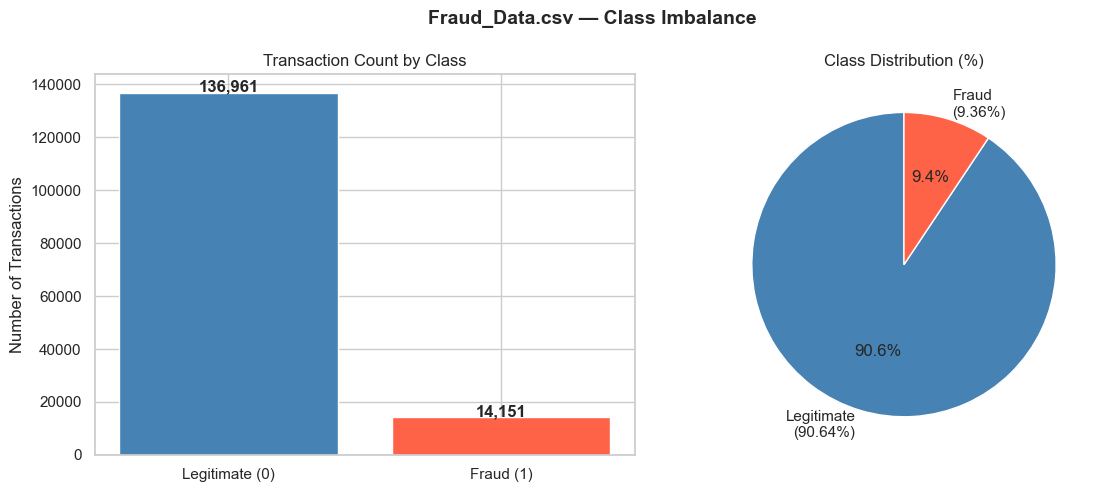

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: count bar chart
axes[0].bar(
    ['Legitimate (0)', 'Fraud (1)'],
    dist['count'],
    color=['steelblue', 'tomato'],
    edgecolor='white'
)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(dist['count']):
    axes[0].text(i, v + 500, f"{v:,}", ha='center', fontweight='bold')

# Right: percentage pie chart
axes[1].pie(
    dist['percentage'],
    labels=['Legitimate\n(90.64%)', 'Fraud\n(9.36%)'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Fraud_Data.csv — Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_imbalance_fraud.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Univariate Analysis — Purchase Value

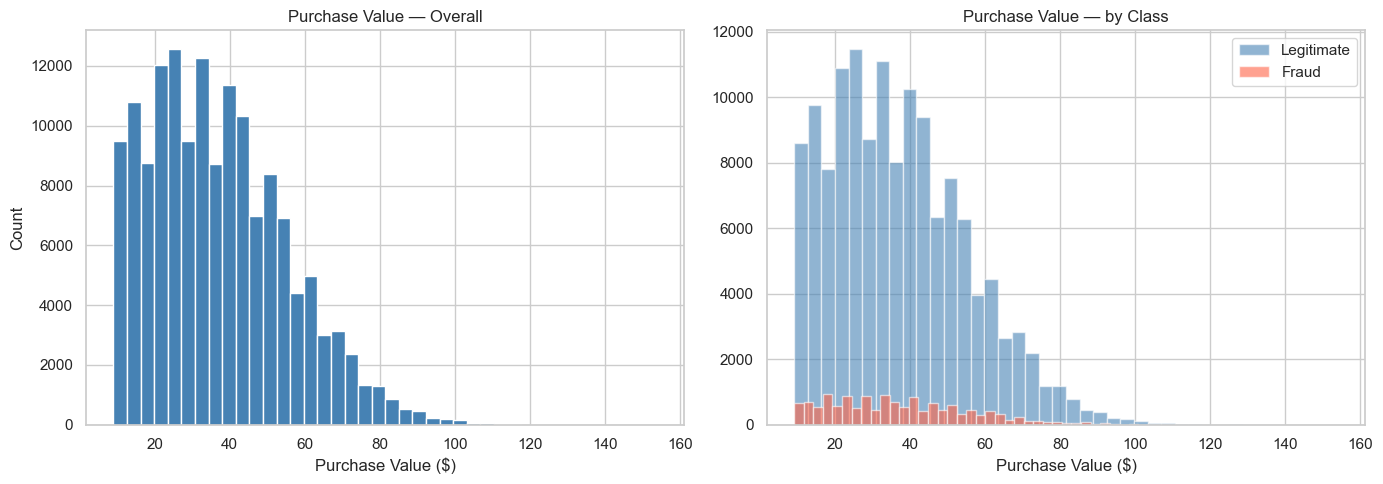

In [11]:
# A histogram shows how a numeric variable is distributed across its range.
# Splitting by class (fraud vs legitimate) reveals if fraud tends to involve
# different purchase amounts.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(fraud['purchase_value'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Purchase Value — Overall')
axes[0].set_xlabel('Purchase Value ($)')
axes[0].set_ylabel('Count')

# By class
for label, color, name in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
    axes[1].hist(
        fraud[fraud['class'] == label]['purchase_value'],
        bins=40, alpha=0.6, color=color, edgecolor='white', label=name
    )
axes[1].set_title('Purchase Value — by Class')
axes[1].set_xlabel('Purchase Value ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'purchase_value_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Univariate Analysis — Age

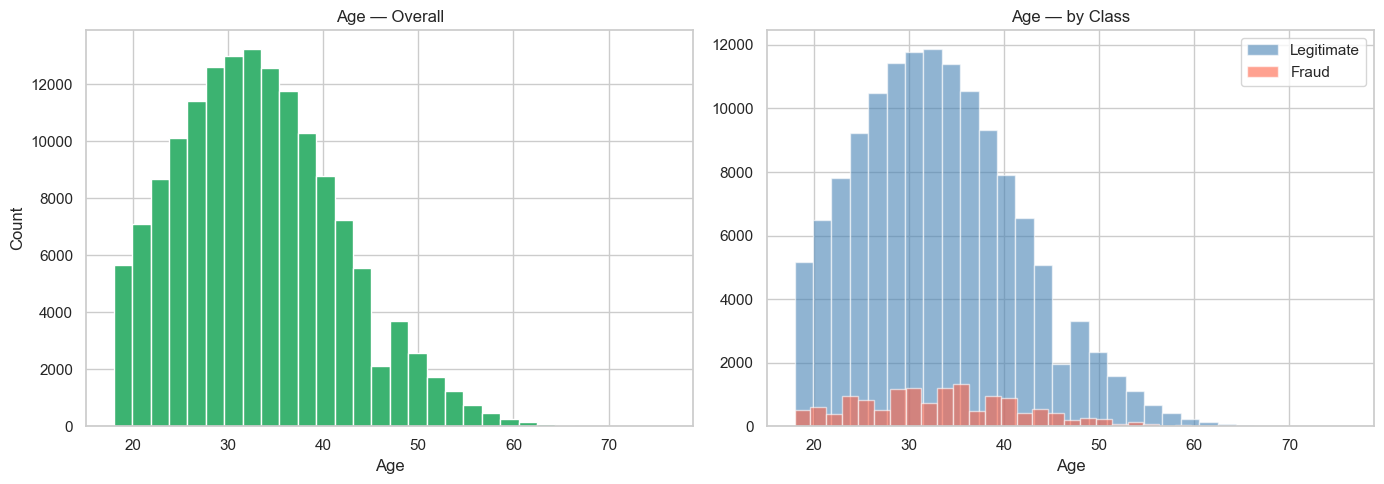

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fraud['age'], bins=30, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Age — Overall')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

for label, color, name in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
    axes[1].hist(
        fraud[fraud['class'] == label]['age'],
        bins=30, alpha=0.6, color=color, edgecolor='white', label=name
    )
axes[1].set_title('Age — by Class')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'age_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Bivariate Analysis — Fraud Rate by Categorical Variables

Instead of raw counts, we compute the **fraud rate** = mean of `class` within each group.
- A group with rate 0.20 means 20% of its transactions are fraud.
- The dashed line shows the overall average rate (9.36%).

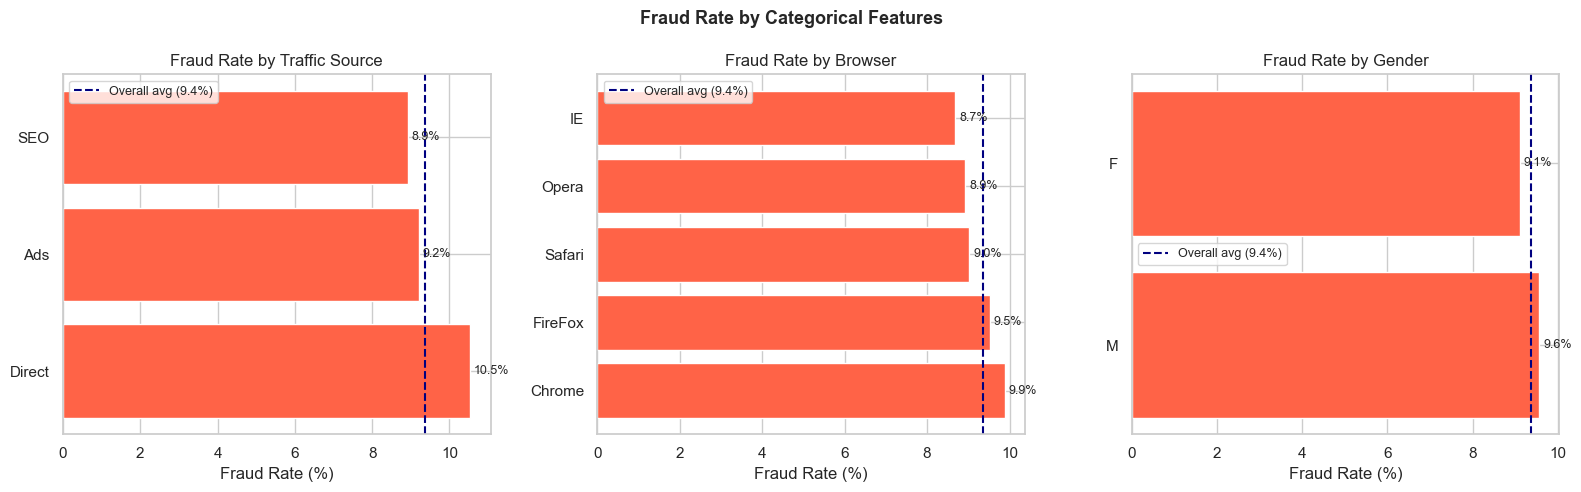

In [13]:
def plot_fraud_rate(df, feature, title, ax):
    """
    Plot fraud rate (%) per category of a feature.
    
    How it works:
      groupby(feature)['class'].mean() gives the fraud proportion per category.
      Multiplying by 100 converts it to a percentage.
    """
    rates = (df.groupby(feature)['class'].mean() * 100).sort_values(ascending=False)
    bars  = ax.barh(rates.index, rates.values, color='tomato', edgecolor='white')
    ax.set_xlabel('Fraud Rate (%)')
    ax.set_title(title)
    ax.axvline(
        df['class'].mean() * 100, color='navy', linestyle='--',
        linewidth=1.5, label=f"Overall avg ({df['class'].mean()*100:.1f}%)"
    )
    ax.legend(fontsize=9)
    for bar, val in zip(bars, rates.values):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va='center', fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_fraud_rate(fraud, 'source',  'Fraud Rate by Traffic Source', axes[0])
plot_fraud_rate(fraud, 'browser', 'Fraud Rate by Browser',        axes[1])
plot_fraud_rate(fraud, 'sex',     'Fraud Rate by Gender',         axes[2])

plt.suptitle('Fraud Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fraud_rate_categorical.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Boxplots — Purchase Value & Age vs Class

C:\Users\gtta1\AppData\Local\Temp\ipykernel_13632\2361919998.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fraud_plot, x='Class Label', y='purchase_value', palette=palette, ax=axes[0])
C:\Users\gtta1\AppData\Local\Temp\ipykernel_13632\2361919998.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fraud_plot, x='Class Label', y='age', palette=palette, ax=axes[1])


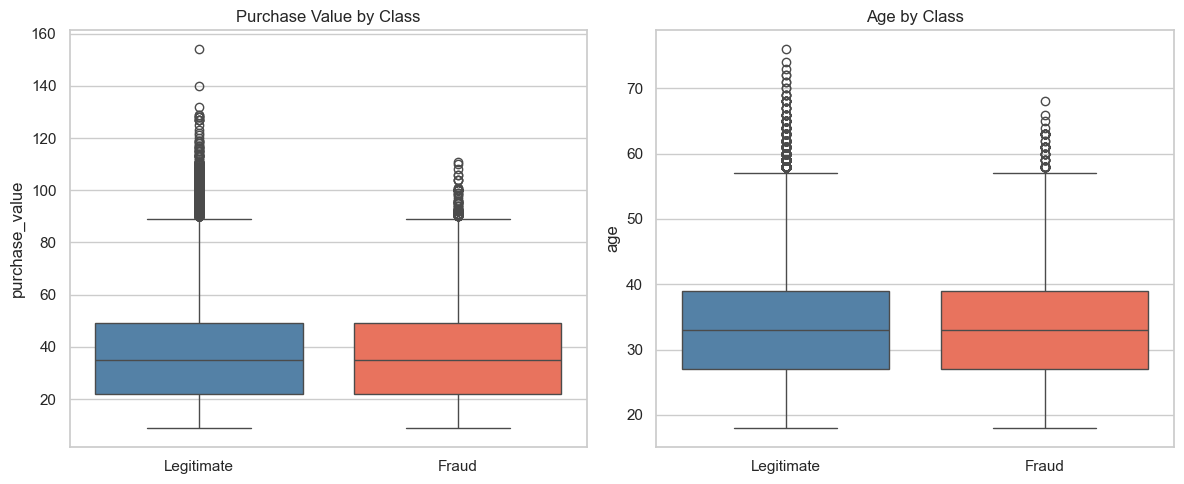

In [14]:
# A boxplot shows: median (middle line), IQR (box), and outliers (dots).
# Comparing class=0 vs class=1 reveals whether fraud correlates with
# higher/lower purchase values or specific age ranges.

fraud_plot = fraud.copy()
fraud_plot['Class Label'] = fraud_plot['class'].map({0: 'Legitimate', 1: 'Fraud'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = {'Legitimate': 'steelblue', 'Fraud': 'tomato'}

sns.boxplot(data=fraud_plot, x='Class Label', y='purchase_value', palette=palette, ax=axes[0])
axes[0].set_title('Purchase Value by Class')
axes[0].set_xlabel('')

sns.boxplot(data=fraud_plot, x='Class Label', y='age', palette=palette, ax=axes[1])
axes[1].set_title('Age by Class')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'boxplots_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Geolocation Integration (IP Address → Country)

**Why?** The country a purchase originates from can be a strong fraud signal.
Transactions from countries where the business doesn't normally operate are suspicious.

**How IP addresses work technically:**
- Every IPv4 address is a 32-bit integer (e.g. `192.168.1.1` = `3,232,235,777`)
- The lookup table lists ranges: any IP where `lower_bound ≤ ip ≤ upper_bound` belongs to a country
- We need to find which range each transaction's IP falls into

### 5.1 Convert IP Float → Integer

In [15]:
# In the CSV, ip_address is stored as float64 due to scientific notation (e.g. 7.33e+08).
# ip_float_to_int() casts it to int64 so it matches the integer bounds in the lookup table.
fraud['ip_int'] = ip_float_to_int(fraud['ip_address'])

print("Sample: float IP vs integer IP")
print(fraud[['ip_address', 'ip_int']].head(5).to_string())

Sample: float IP vs integer IP
     ip_address      ip_int
0  732758368.80   732758368
1  350311387.87   350311387
2 2621473820.11  2621473820
3 3840542443.91  3840542443
4  415583117.45   415583117


### 5.2 Range-Based Merge

**Why `pd.merge_asof` instead of a regular merge?**

A normal `.merge()` requires an exact key match. But we need: *"find the range where lower ≤ ip ≤ upper"*.
With 151K transactions and 138K ranges, a brute-force loop would do 21 billion comparisons.

`merge_asof`:
1. Sorts both tables by their join keys
2. Does a binary search to find the closest `lower_bound` that is still ≤ each `ip_int`
3. Then we validate that `ip_int ≤ upper_bound`

This reduces 21 billion comparisons to ~151K binary searches — orders of magnitude faster.

In [16]:
print("Running IP → Country merge ...")
fraud_geo = merge_ip_country(fraud, ip_country)
print("✓ Merge complete")

n_unknown  = (fraud_geo['country'] == 'Unknown').sum()
pct_unknown = n_unknown / len(fraud_geo) * 100
print(f"\nIPs matched to a country : {len(fraud_geo) - n_unknown:,} ({100 - pct_unknown:.1f}%)")
print(f"IPs with no match (Unknown): {n_unknown:,} ({pct_unknown:.1f}%)")

Running IP → Country merge ...
✓ Merge complete

IPs matched to a country : 129,146 (85.5%)
IPs with no match (Unknown): 21,966 (14.5%)


In [17]:
fraud_geo[['user_id', 'ip_address', 'ip_int', 'country', 'class']].head(10)

,user_id,ip_address,ip_int,country,class
0,62421,52093.50,52093,Unknown,0
1,173212,93447.14,93447,Unknown,0
2,242286,105818.50,105818,Unknown,0
3,370003,117566.66,117566,Unknown,0
4,119824,131423.79,131423,Unknown,0
5,266190,155130.40,155130,Unknown,0
6,241175,155399.11,155399,Unknown,0
7,138971,159119.79,159119,Unknown,0
8,377916,166326.78,166326,Unknown,0
9,21325,207999.64,207999,Unknown,0


### 5.3 Fraud Patterns by Country

In [18]:
# Calculate fraud rate per country, keep top 20 by fraud rate
country_stats = (
    fraud_geo.groupby('country')['class']
    .agg(total='count', fraud_count='sum')
    .assign(fraud_rate=lambda x: x['fraud_count'] / x['total'] * 100)
    .sort_values('fraud_rate', ascending=False)
    .head(20)
)

print("Top 20 countries by fraud rate:")
print(country_stats.to_string())

Top 20 countries by fraud rate:
                       total  fraud_count  fraud_rate
country                                              
Turkmenistan               1            1      100.00
Namibia                   23           10       43.48
Sri Lanka                 31           13       41.94
Luxembourg                72           28       38.89
Virgin Islands (U.S.)      3            1       33.33
Ecuador                  106           28       26.42
Tunisia                  118           31       26.27
Peru                     119           31       26.05
Bolivia                   53           13       24.53
Kuwait                    90           21       23.33
Ireland                  240           55       22.92
New Zealand              278           62       22.30
Uzbekistan                10            2       20.00
Lithuania                 95           18       18.95
Saudi Arabia             264           50       18.94
Malta                     22            4       18

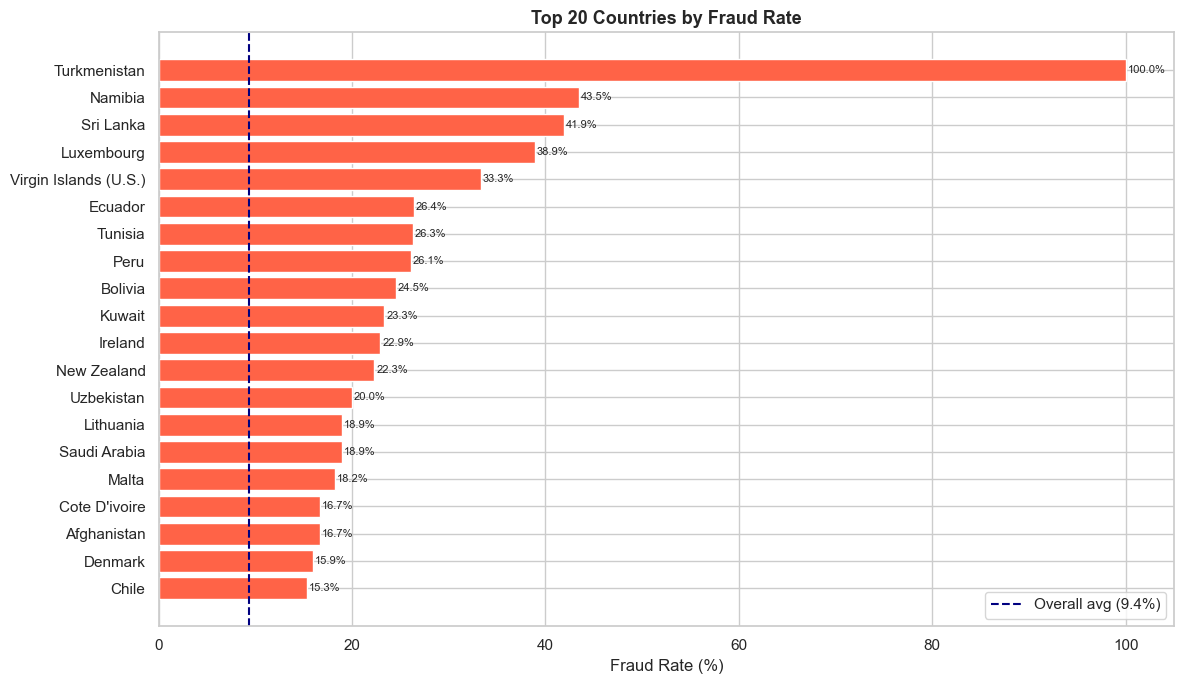

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(country_stats.index, country_stats['fraud_rate'],
               color='tomato', edgecolor='white')
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Top 20 Countries by Fraud Rate', fontsize=13, fontweight='bold')
ax.axvline(
    fraud_geo['class'].mean() * 100,
    color='navy', linestyle='--', linewidth=1.5,
    label=f"Overall avg ({fraud_geo['class'].mean()*100:.1f}%)"
)
ax.legend()
ax.invert_yaxis()

for bar, val in zip(bars, country_stats['fraud_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fraud_rate_by_country.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Cleaned Data

In [20]:
# Save the enriched dataset (with ip_int and country columns added).
# The feature_engineering notebook will load from this file.
output_path = os.path.join(DATA_PROCESSED, 'fraud_data_cleaned.csv')
fraud_geo.to_csv(output_path, index=False)

print(f"✓ Saved to: {output_path}")
print(f"   Shape   : {fraud_geo.shape}")
print(f"   Columns : {list(fraud_geo.columns)}")

✓ Saved to: ..\data\processed\fraud_data_cleaned.csv
   Shape   : (151112, 13)
   Columns : ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'ip_int', 'country']


## Summary of EDA Findings

| Finding | Detail |
|---------|--------|
| **Missing values** | None — no imputation needed |
| **Duplicates** | None |
| **Class imbalance** | 9.36% fraud — moderate; SMOTE required on training data |
| **Purchase value** | Similar distributions across classes (mean ≈ $37) |
| **Age** | Fraud slightly more concentrated in younger users |
| **Geolocation** | Some countries show notably higher fraud rates |
| **Next step** | Feature engineering → `feature_engineering.ipynb` |